# Fraud Detection in Electricity and Gas Consumption Challenge

## Import Libraries

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, precision_recall_curve, fbeta_score

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier


## Download and extract files

In [2]:
client_train = pd.read_csv('data/train/client_train.csv', low_memory=False)

In [3]:
invoice_train = pd.read_csv('data/train/invoice_train.csv', low_memory=False)

In [4]:
client_test = pd.read_csv('data/test/client_test.csv', low_memory=False)

In [5]:
invoice_test = pd.read_csv('data/test/invoice_test.csv', low_memory=False)

# Data Prep

## Data Understanding

In [6]:
#compare size of the various datasets
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_train.shape)

(135493, 6) (4476749, 16) (58069, 5) (4476749, 16)


In [7]:
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [8]:
client_test.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
dtype: int64

In [9]:
client_train.target.unique()

array([0., 1.])

In [10]:
invoice_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


In [11]:
counter_stats = invoice_train.groupby('counter_type')[
    ['consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4']
].agg(['mean', 'max', 'std'])

print(counter_stats.T)

counter_type                        ELEC            GAZ
consommation_level_1 mean     507.918803     197.348707
                     max    99920.000000  999910.000000
                     std      597.984711     991.476389
consommation_level_2 mean     158.122399       1.779250
                     max   999073.000000   29806.000000
                     std     1466.627210     111.135413
consommation_level_3 mean      29.520556       0.000000
                     max    64492.000000       0.000000
                     std      189.091928       0.000000
consommation_level_4 mean      76.942075       0.000000
                     max   547946.000000       0.000000
                     std     1054.702565       0.000000


In [12]:
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [13]:
invoice_train.counter_coefficient.value_counts()

counter_coefficient
1     4475102
2         886
3         321
40        197
30        137
0          46
6          30
4          12
10          6
20          3
9           3
50          2
33          1
5           1
11          1
8           1
Name: count, dtype: int64

In [14]:
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [15]:
client_train.disrict.unique()

array([60, 69, 62, 63], dtype=int64)

No missing values in train set

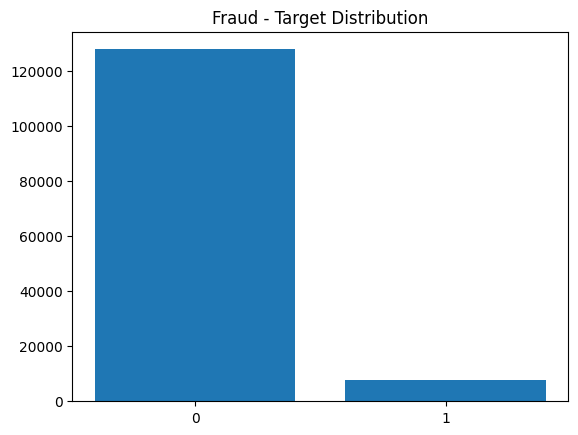

In [16]:
fraudactivities = client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

Target is highly imbalanced with fewer cases of fraudulent activities

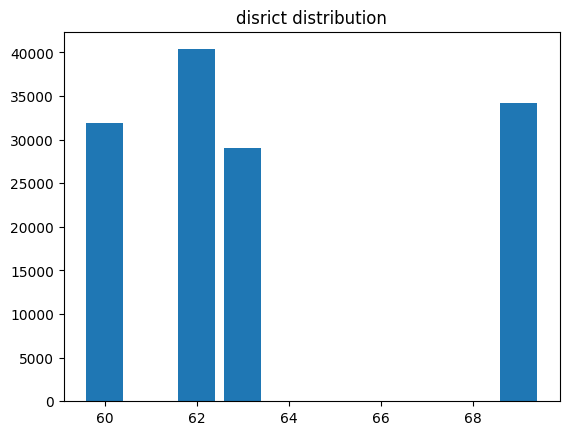

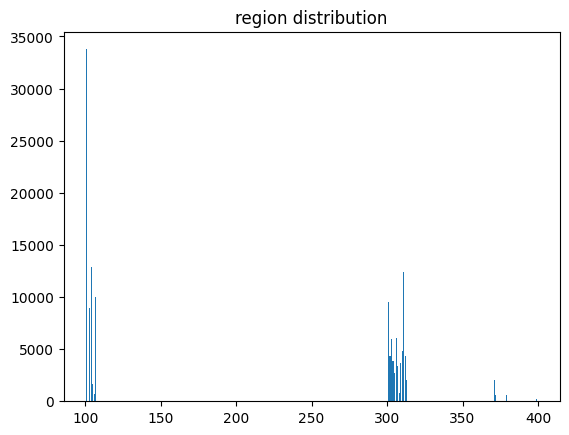

In [17]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

## Feature Engineering

In [18]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [19]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [20]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

### Manual Aggreagation

In [21]:
# find consumption levels and amounts for each clients
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_2'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_3'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_4'] = ['mean', 'max', 'min', 'std', 'sum']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = [''.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [22]:
agg_train = aggregate_by_client_id(invoice_train)

print(agg_train.shape)
agg_train.head()

(135493, 22)


,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3mean,consommation_level_3max,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,117.357143,800,0,289.433294,1643,36.714286,382,0,105.421081,514


In [23]:
# calculate the consumption from the counter's index
invoice_train['calc_index'] = invoice_train['new_index'] - invoice_train['old_index']

In [24]:
# aggregate each invoice's index for each client
calc_index_sum = invoice_train.groupby('client_id')['calc_index'].sum()

agg_train_index = pd.merge(agg_train, calc_index_sum, on='client_id', how='left')

agg_train_index.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3max,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,12704
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,20629
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,15057
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,24
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,800,0,289.433294,1643,36.714286,382,0,105.421081,514,12917


In [25]:
# we want to know the last tarif the client uses to interpret the consumption levels
calc_tarif_type = invoice_train.groupby('client_id')['tarif_type'].last()

agg_train_tarif = pd.merge(agg_train_index, calc_tarif_type, on='client_id', how='left')

In [26]:
agg_train_tarif.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,12704,11
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,20629,11
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,15057,11
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,24,11
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,0,289.433294,1643,36.714286,382,0,105.421081,514,12917,11


In [27]:
## we want to know the counter coefficienct of the client uses to interpret the consumption levels

calc_counter_coeff = invoice_train.groupby('client_id')['counter_coefficient'].last()

agg_train_coeff = pd.merge(agg_train_tarif, calc_counter_coeff, on='client_id', how='left')

In [28]:
agg_train_coeff.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0.000000,0,0,0.000000,0,12704,11,1
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0.000000,0,0,0.000000,0,20629,11,1
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0.000000,0,0,0.000000,0,15057,11,1
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0.000000,0,0,0.000000,0,24,11,1
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,289.433294,1643,36.714286,382,0,105.421081,514,12917,11,1


In [29]:
agg_train_coeff.counter_coefficient.value_counts()

counter_coefficient
1     135455
2         20
3          9
40         2
6          2
50         1
20         1
30         1
4          1
0          1
Name: count, dtype: int64

In [30]:
energy_features = (
    invoice_train
    .groupby('client_id')['counter_type']
    .agg(
        has_electricity=lambda x: int((x == 0).any()),
        has_gas=lambda x: int((x == 1).any())
    )
    .reset_index()
)

In [31]:
energy_features

,client_id,has_electricity,has_gas
0,train_Client_0,1,0
1,train_Client_1,1,0
2,train_Client_10,1,0
3,train_Client_100,1,0
4,train_Client_1000,1,0
...,...,...,...
135488,train_Client_99995,1,1
135489,train_Client_99996,1,1
135490,train_Client_99997,1,1
135491,train_Client_99998,1,0


In [32]:
agg_train_all = pd.merge(agg_train_coeff, energy_features, on='client_id', how='left')
agg_train_all

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,71,1.957746,139,0,16.496265,139,0.000000,0,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,train_Client_99996,41,185.853659,800,0,200.935258,7620,0.756098,31,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,train_Client_99997,36,273.083333,1075,33,211.123441,9831,0.000000,0,0,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,train_Client_99998,2,300.000000,400,200,141.421356,600,70.500000,135,6,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [33]:
aggregated_manually = pd.merge(client_train,agg_train_all, on='client_id', how='left')

In [34]:
aggregated_manually

,disrict,client_id,client_catg,region,creation_date,target,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,...,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,1200,38,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,1207,190,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,2400,188,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,15,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,800,124,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,139,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,800,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,1075,33,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,400,200,...,0.000000,0,0,0.000000,0,741,10,1,1,0


### Aggregation Function

In [21]:
def agg_merged_datasets(client, invoice):

    # --- aggregation consumption levels ---
    aggs = {}
    aggs['consommation_level_1'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_2'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_3'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_4'] = ['mean', 'max', 'min', 'std', 'sum']

    agg_trans = invoice.groupby('client_id').agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    # --- number of transactions per client ---
    df = (
        invoice.groupby('client_id')
        .size()
        .reset_index(name='transactions_count')
    )

    agg_data = pd.merge(df, agg_trans, on='client_id', how='left')

    # --- calc_index feature ---
    invoice['calc_index'] = invoice['new_index'] - invoice['old_index']

    calc_index_sum = (
        invoice.groupby('client_id')['calc_index']
        .sum()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_index_sum, on='client_id', how='left')

    # --- tarif type ---
    calc_tarif_type = (
        invoice.groupby('client_id')['tarif_type']
        .last()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_tarif_type, on='client_id', how='left')

    # --- counter coefficient ---
    calc_counter_coeff = (
        invoice.groupby('client_id')['counter_coefficient']
        .last()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_counter_coeff, on='client_id', how='left')

    # --- electricity / gas features ---
    energy_features = (
        invoice
        .groupby('client_id')['counter_type']
        .agg(
            has_electricity=lambda x: int((x == 0).any()),
            has_gas=lambda x: int((x == 1).any())
        )
        .reset_index()
    )

    agg_data = pd.merge(agg_data, energy_features, on='client_id', how='left')

    # --- merge with client table ---
    final_df = pd.merge(client, agg_data, on='client_id', how='left')

    return final_df

In [22]:
train_combined = agg_merged_datasets(client_train, invoice_train)

In [23]:
train_combined.shape

(135493, 32)

In [24]:
test_combined = agg_merged_datasets(client_test, invoice_test)

In [25]:
test_combined.shape

(58069, 31)

In [26]:
train_combined 

,disrict,client_id,client_catg,region,creation_date,target,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,1200,38,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,1207,190,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,2400,188,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,15,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,800,124,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,139,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,800,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,1075,33,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,400,200,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [27]:
test_combined

,disrict,client_id,client_catg,region,creation_date,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,62,test_Client_0,11,307,28/05/2002,37,488.135135,1090,0,230.388942,...,0.000000,0,0,0.000000,0,18181,11,1,1,0
1,69,test_Client_1,11,103,06/08/2009,22,1091.409091,3600,11,739.185437,...,586.318182,12899,0,2750.076040,12899,59470,11,1,1,0
2,62,test_Client_10,11,310,07/04/2004,74,554.040541,1200,0,346.775891,...,0.162162,12,0,1.394972,12,44941,40,1,1,1
3,60,test_Client_100,11,101,08/10/1992,40,244.350000,721,0,247.253171,...,0.000000,0,0,0.000000,0,9774,11,1,1,1
4,62,test_Client_1000,11,301,21/07/1977,53,568.188679,2400,0,486.891871,...,0.000000,0,0,0.000000,0,39703,11,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58064,63,test_Client_9995,11,399,17/03/2010,4,461.250000,938,0,532.755964,...,0.000000,0,0,0.000000,0,1845,11,1,1,1
58065,63,test_Client_9996,11,311,28/05/2011,46,181.565217,456,0,107.556838,...,0.000000,0,0,0.000000,0,8352,40,1,1,1
58066,60,test_Client_9997,11,101,04/03/1978,59,160.559322,739,22,104.969334,...,0.000000,0,0,0.000000,0,10177,10,1,1,1
58067,60,test_Client_9998,11,101,23/02/2018,1,800.000000,800,800,NaN,...,0.000000,0,0,NaN,0,1927,11,1,1,0


In [28]:
X_train = train_combined.drop(columns=['client_id', 'creation_date', 'target', 'region'])
X_train

,disrict,client_catg,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,consommation_level_2_max,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,11,35,352.400000,1200,38,310.343472,12334,10.571429,186,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,11,37,557.540541,1207,190,197.935960,20629,0.000000,0,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,11,18,798.611111,2400,188,513.841374,14375,37.888889,682,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,11,20,1.200000,15,0,3.607011,24,0.000000,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,11,14,663.714286,800,124,224.831365,9292,104.857143,400,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,11,71,1.957746,139,0,16.496265,139,0.000000,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,11,41,185.853659,800,0,200.935258,7620,0.756098,31,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,11,36,273.083333,1075,33,211.123441,9831,0.000000,0,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,11,2,300.000000,400,200,141.421356,600,70.500000,135,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [29]:
y_train = train_combined['target']
y_train

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
135488    0.0
135489    0.0
135490    0.0
135491    0.0
135492    0.0
Name: target, Length: 135493, dtype: float64

In [30]:
X_test = test_combined.drop(columns=['client_id', 'creation_date', 'region'])
X_test

,disrict,client_catg,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,consommation_level_2_max,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,62,11,37,488.135135,1090,0,230.388942,18061,3.243243,120,...,0.000000,0,0,0.000000,0,18181,11,1,1,0
1,69,11,22,1091.409091,3600,11,739.185437,24011,843.136364,4053,...,586.318182,12899,0,2750.076040,12899,59470,11,1,1,0
2,62,11,74,554.040541,1200,0,346.775891,40999,37.364865,400,...,0.162162,12,0,1.394972,12,44941,40,1,1,1
3,60,11,40,244.350000,721,0,247.253171,9774,0.000000,0,...,0.000000,0,0,0.000000,0,9774,11,1,1,1
4,62,11,53,568.188679,2400,0,486.891871,30114,145.056604,1362,...,0.000000,0,0,0.000000,0,39703,11,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58064,63,11,4,461.250000,938,0,532.755964,1845,0.000000,0,...,0.000000,0,0,0.000000,0,1845,11,1,1,1
58065,63,11,46,181.565217,456,0,107.556838,8352,0.000000,0,...,0.000000,0,0,0.000000,0,8352,40,1,1,1
58066,60,11,59,160.559322,739,22,104.969334,9473,11.932203,248,...,0.000000,0,0,0.000000,0,10177,10,1,1,1
58067,60,11,1,800.000000,800,800,NaN,800,400.000000,400,...,0.000000,0,0,NaN,0,1927,11,1,1,0


#### Checking data for correlations

In [31]:
target_corr = X_train.join(y_train).corr()['target'].sort_values(ascending=False)
print("Top 5 Features Correlated with Fraud:")
print(target_corr.head(6))

Top 5 Features Correlated with Fraud:
target                      1.000000
transactions_count          0.127044
consommation_level_3_max    0.098889
consommation_level_1_sum    0.088080
consommation_level_3_std    0.081967
consommation_level_3_sum    0.071659
Name: target, dtype: float64


#### Checking data for multicollinearity

In [32]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"\nRedundant features: {len(to_drop)}")
print(to_drop)


Redundant features: 2
['consommation_level_3_std', 'consommation_level_4_std']


## Validation set

In [33]:
X_sub, X_val, y_sub, y_val = train_test_split(X_train, y_train, test_size=0.33, random_state=42, stratify=y_train)

In [34]:
X_sub

,disrict,client_catg,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,consommation_level_2_max,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
112281,69,11,46,879.565217,4000,75,800.153087,40460,799.739130,3896,...,0.0,0,0,0.0,0,-21056,40,1,1,1
64536,60,11,7,647.285714,1373,262,440.090791,4531,0.000000,0,...,0.0,0,0,0.0,0,4531,11,1,1,0
87268,62,11,20,428.600000,1474,205,283.203368,8572,0.000000,0,...,0.0,0,0,0.0,0,8572,11,1,1,0
114652,60,11,56,298.053571,1196,0,316.970169,16691,0.000000,0,...,0.0,0,0,0.0,0,16691,11,1,1,1
20549,62,11,64,244.484375,676,39,167.151010,15647,119.734375,474,...,0.0,0,0,0.0,0,23310,10,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18535,60,11,24,132.541667,668,0,169.733033,3181,0.000000,0,...,0.0,0,0,0.0,0,3181,11,1,1,0
8615,62,11,42,999.142857,1200,722,187.992939,41964,214.857143,960,...,0.0,0,0,0.0,0,51999,11,1,1,0
90010,69,11,67,297.611940,1162,0,260.094619,19940,0.000000,0,...,0.0,0,0,0.0,0,19810,11,1,1,1
86943,62,11,27,206.888889,649,6,203.458999,5586,0.000000,0,...,0.0,0,0,0.0,0,5586,11,1,1,1


#### Creating a Pipeline for Data Processing

In [35]:
# Define Column Groups
cat_cols = ['disrict', 'client_catg', 'tarif_type', 'has_electricity', 'has_gas']

num_cols = [col for col in X_train.columns if col not in cat_cols 
            and col not in ['client_id', 'creation_date', 'target']]

# Define the Pipelines
cat_pipeline = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', RobustScaler())
])


# Create the master Processor
processor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ],
    remainder='drop'
)

In [36]:
X_test.shape

(58069, 28)

In [37]:
X_sub_processed = processor.fit_transform(X_sub)

X_val_processed = processor.transform(X_val)
X_test_processed = processor.transform(X_test)

C:\Users\Zeynep\Desktop\DS\ds-ml-project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [38]:
X_test_processed.shape

(58069, 42)

# Modelling

### Baseline Model

In [39]:
logreg = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000,        
    solver='lbfgs',       
    random_state=42,
    n_jobs=-1            
)

logreg.fit(X_sub_processed, y_sub)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [40]:
# Prob of fraud class
val_probs_lr = logreg.predict_proba(X_val_processed)[:, 1]

# AUC calculation
auc_lr = roc_auc_score(y_val, val_probs_lr)
print(f"--- LogReg Baseline AUC: {auc_lr:.4f} ---")

# Check Recall (default 0.5 threshold)
val_preds_lr = logreg.predict(X_val_processed)
print("\nClassification Report (Baseline):")
print(classification_report(y_val, val_preds_lr))

--- LogReg Baseline AUC: 0.7046 ---

Classification Report (Baseline):
              precision    recall  f1-score   support

         0.0       0.97      0.68      0.80     42216
         1.0       0.10      0.62      0.17      2497

    accuracy                           0.67     44713
   macro avg       0.53      0.65      0.49     44713
weighted avg       0.92      0.67      0.76     44713



## Train XGBoost

In [43]:
xgb_base = XGBClassifier(
    scale_pos_weight=17, 
    tree_method='hist', 
    random_state=42,
    n_jobs=-1
)


param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


xgb_search = RandomizedSearchCV(
    xgb_base, 
    param_distributions=param_dist, 
    n_iter=10, 
    scoring='roc_auc', 
    cv=3, 
    verbose=1,
    random_state=42
)


xgb_search.fit(X_sub_processed, y_sub)
best_model = xgb_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [53]:
print(xgb_search.best_params_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [54]:
print(f"Best Search AUC: {xgb_search.best_score_:.4f}")

Best Search AUC: 0.7550


In [55]:
val_probs = best_model.predict_proba(X_val_processed)[:, 1]

print(f"XGBoost Validation AUC: {roc_auc_score(y_val, val_probs):.4f}")

XGBoost Validation AUC: 0.7573


In [72]:
threshold = 0.5
val_preds = (val_probs >= threshold).astype(int)

print(f"\n--- Results at Threshold {threshold} ---")
print(f"Recall: {recall_score(y_val, val_preds):.4f}")
print(f"Precision: {precision_score(y_val, val_preds):.4f}")
print("\nFull Report:")
print(classification_report(y_val, val_preds))


--- Results at Threshold 0.5 ---
Recall: 0.6976
Precision: 0.1103

Full Report:
              precision    recall  f1-score   support

         0.0       0.97      0.67      0.79     42216
         1.0       0.11      0.70      0.19      2497

    accuracy                           0.67     44713
   macro avg       0.54      0.68      0.49     44713
weighted avg       0.93      0.67      0.76     44713



In [60]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (val_probs >= t).astype(int)
    r = recall_score(y_val, preds)
    p = precision_score(y_val, preds)
    print(f"Threshold {t:.1f} | Recall: {r:.4f} | Precision: {p:.4f}")

Threshold 0.3 | Recall: 0.9243 | Precision: 0.0805
Threshold 0.4 | Recall: 0.8538 | Precision: 0.0917
Threshold 0.5 | Recall: 0.6976 | Precision: 0.1103
Threshold 0.6 | Recall: 0.4826 | Precision: 0.1415
Threshold 0.7 | Recall: 0.2563 | Precision: 0.2063


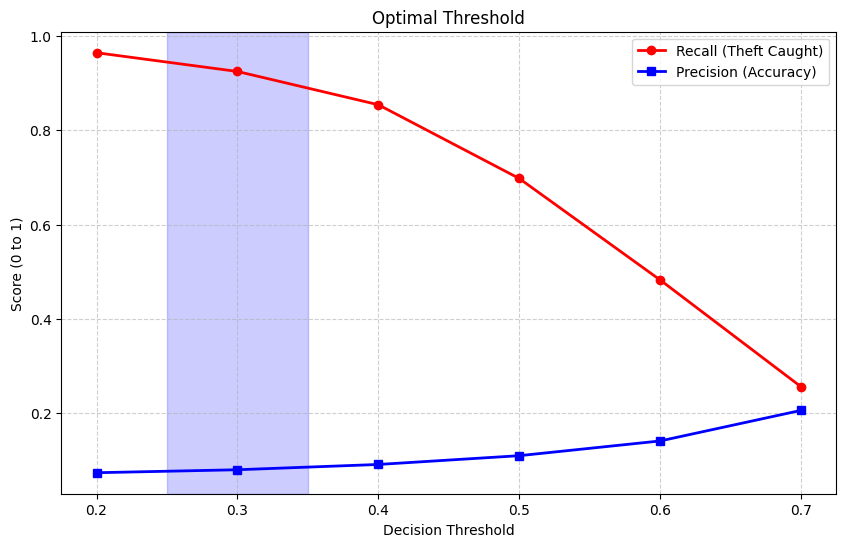

In [71]:
# Using your actual results from earlier
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
recalls = [0.9640, 0.9243, 0.8538, 0.6976, 0.4826, 0.2563]
precisions = [0.0742, 0.0805, 0.0917, 0.1103, 0.1415, 0.2063]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, recalls, marker='o', label='Recall (Theft Caught)', color='red', linewidth=2)
plt.plot(thresholds, precisions, marker='s', label='Precision (Accuracy)', color='blue', linewidth=2)

# Highlighting the "Business Zone"
plt.axvspan(0.25, 0.35, color='blue', alpha=0.2)

plt.title('Optimal Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score (0 to 1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [73]:
threshold_final = 0.3
val_preds = (val_probs >= threshold_final).astype(int)

print(f"\n--- Results at Threshold {threshold_final} ---")
print(f"Recall: {recall_score(y_val, val_preds):.4f}")
print(f"Precision: {precision_score(y_val, val_preds):.4f}")
print("\nFull Report:")
print(classification_report(y_val, val_preds))


--- Results at Threshold 0.3 ---
Recall: 0.9243
Precision: 0.0805

Full Report:
              precision    recall  f1-score   support

         0.0       0.99      0.38      0.54     42216
         1.0       0.08      0.92      0.15      2497

    accuracy                           0.41     44713
   macro avg       0.53      0.65      0.35     44713
weighted avg       0.94      0.41      0.52     44713



### Train an Ensemle Method, Random Forest and XGBoost

In [74]:
xgb_best = xgb_search.best_estimator_

rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

ensemble_model = VotingClassifier(
    estimators=[('xgb', xgb_best), ('rf', rf_model)],
    voting='soft',
    weights=[1, 1] # Equal weight to both
)

ensemble_model.fit(X_sub_processed, y_sub)

ens_probs = ensemble_model.predict_proba(X_val_processed)[:, 1]
print(f"Ensemble Validation AUC: {roc_auc_score(y_val, ens_probs):.4f}")

Ensemble Validation AUC: 0.7517


## Make Predictions on test set based on final XGBoost Model

In [80]:
test_probs = best_model.predict_proba(X_test_processed)[:, 1]

final_preds = (test_probs >= 0.3).astype(int)


test_predictions = pd.DataFrame({
    'client_id': test_combined['client_id'], 
    'target': final_preds
})

test_predictions.to_csv('STEG_Final_Submission.csv', index=False)